**FEBS PRACTICAL COURSE 2026: Generative AI for protein engineering**

**Notebook developed by Núria Mimbrero.**

# **1. Language Models for Protein Design**


## **1.1. Proteins Natural Grammar 📑**

* **For years scientists have curated millions of Protein Sequences from the whole treee of Life**

Because proteins can perform a wide range of powerful and versatile functionalities. For instance, natural proteins can accelerate chemical reactions and regulate every biological process within cells and organisms.

* **Proteins are defined as a Grammar**

Design proteins with customized functionalities.


* **Why can we apply ML to proteins?**

Several characteristics evidence the **similarities between human languages
and protein sequences**, with perhaps the most obvious being
their hierarchical organization.

Analogous to human languages,proteins are represented by a concatenation of strings: the 20 standard amino acids. Letters then assemble to form words, and amino acids combine to form secondary structural elements or conserved
protein fragments. Then, as words combine to form sentences that
carry meaning, fragments can assemble into different protein structures
that carry a function

The associations also span other behaviours observed
in proteins. The detrimental effect of adding or changing
one letter in a sentence’s meaning is equivalent to a loss of function
caused by a single mutation. The possibility of shuffling words
while still preserving meaning is comparable to sequence permutation.
Finally, the formulation of a grammatically correct but
meaningless sentence is analogous to designed protein structures
with no apparent function or even dangerous functions, such as
amyloid fibrils.


Because ofthis similarities between the two fields (natural and protein language), **representing proteins as a linear string** of aminoacids can constitute the language to train language models.



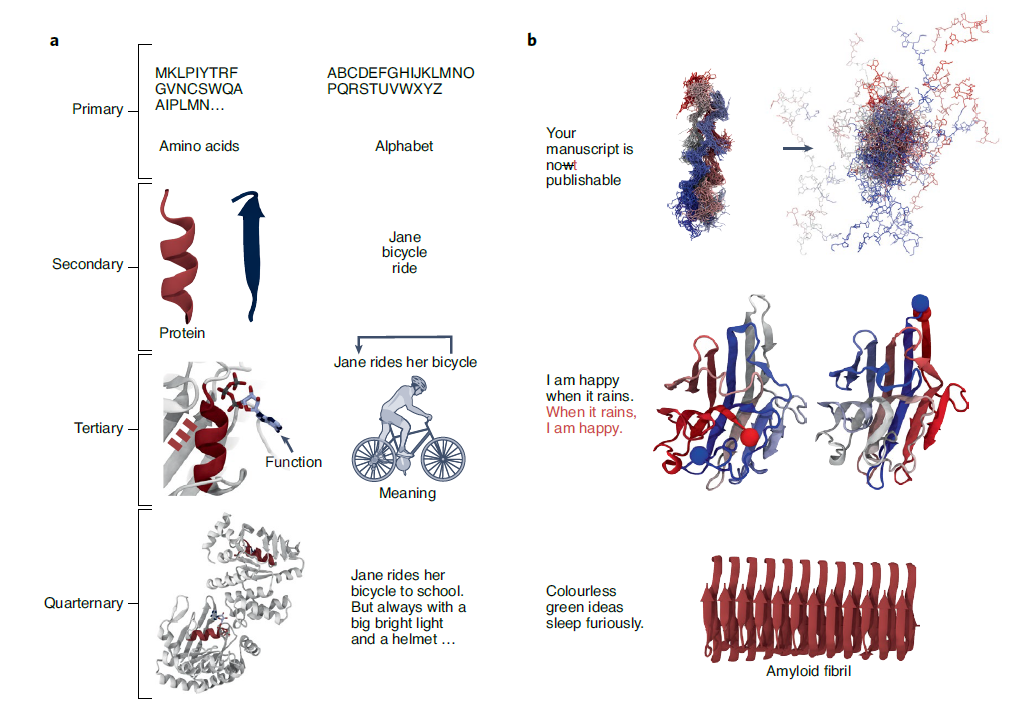

Ferruz et al. Controllable protein design with language models. Nature Machine
Intelligence (2022)




**Provided a protein sequence we can use statistical information to infer it's likelihood compared to the natural distribution**




##**2. Protein Language Models** 🚀

### **2.1. What are PLM?**

PLM are large language models trained on very large datasets of proteins to capture the relationship between sequence, structure and/or function.

PLM learn the fitness landscape explored by nature to aply it to tasks like protein design or protein property prediction.

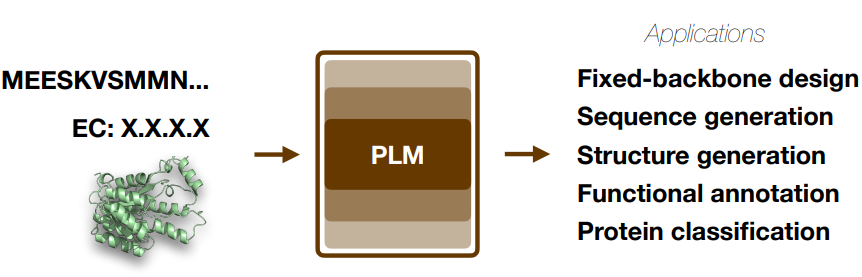

### **2.2. Transformers**
**What are they and why they are a revolution?**

Transformers are a deep learning model that uses the **attention mechanism** to focus on specific parts of the input data to generate the output.

The attention mechanism emerged as a critical development in AI. Compared to previous seq2seq (sequence to sequence) models, transformers decrease computational time (because it allows parallel computation) and allow long-range dependencies.

### **2.3. Architecture of Transformers**

The original transformer model is composed by an encoder and a decoder.


* **Before the transformer process the sentence...**
    
    we break down the sentence into smaller chunks (tokenization) and we convert each part into a vector (embedding).Finally, we add position encoding to help the model know the position of each token in the sequence.

* **The encoder processes the embeddings using the multi-head self-attention sub-layer and the feed foward sub-layer**.

  First, the self-attention captures contextual information of each part of the input. Then, this is passed to the feed forward sub-layer to produce a vector representation that captures the context of each part in respect to the entire input.
  This vector is then passed to the decoder.
  
* **The decoder takes the encoded sequences and uses it to generate the output, token by token.**
  
   In the decoder, the **masked self-attention** sub-layer is used to mask the information to be sure the prediction of a token only depends on the tokens already generated. The decoder layers contain the two sublayers present in the encoder (**multi-head attention and feed fowards**)to focus on relevant parts of all the output generated by the encoder to create the final output.

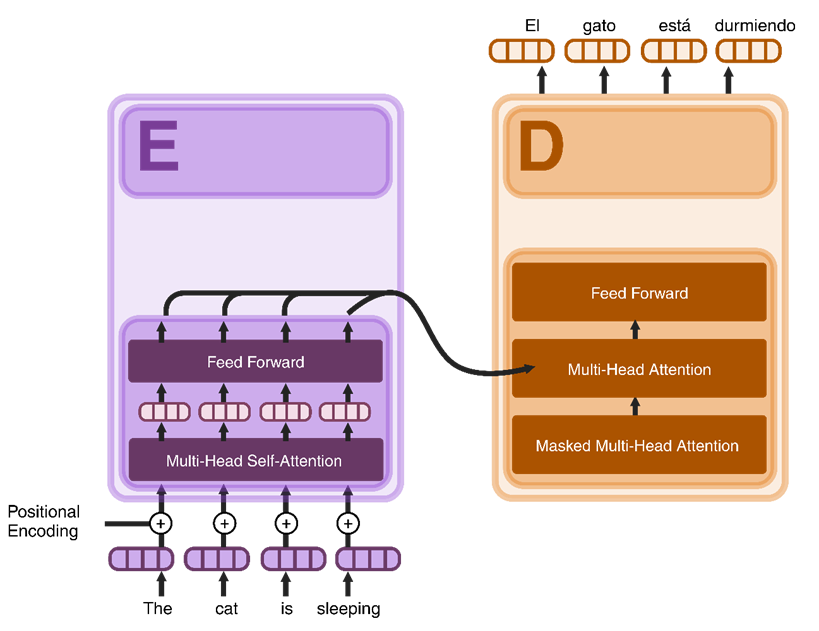

### **2.4. Encoder-only and Decoder-only transformers**

Versions of the transformer but using only one part of the original transformer.
* **Encode-only models**: use the encoder part of the transformer to create reperesentations of the input text. Traning by reconstructing a masked sentence (**masking**).
    * Applications: classification tasks.
    * Example: **BERT** (bidirectional encoder representation)
* **Decoder-only models**: use the decoder part of the transformer to generate sentences. Training by predicting the next item based on the previous ones (**autoregressive**)
    * Applications: generative tasks.
    * Example: **GPT**

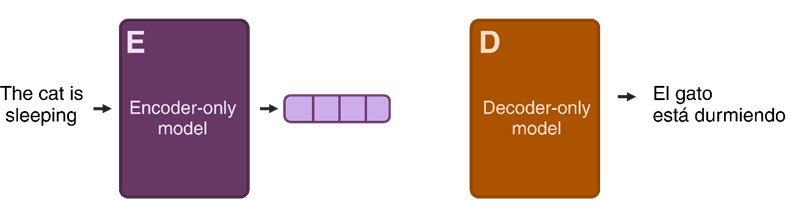

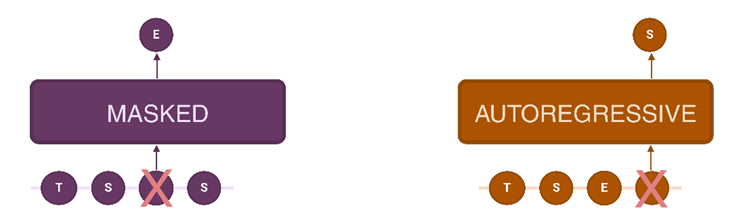

### **2.5. Decoder-only transformers**

Key for protein design since they can generate sentences. Adding aminoacids from the N-terminal to the C-terminal part of the protein.

This models can be used in an unconditional fashion, where they explore the protein space by sampling sequences according to the probability they learned.





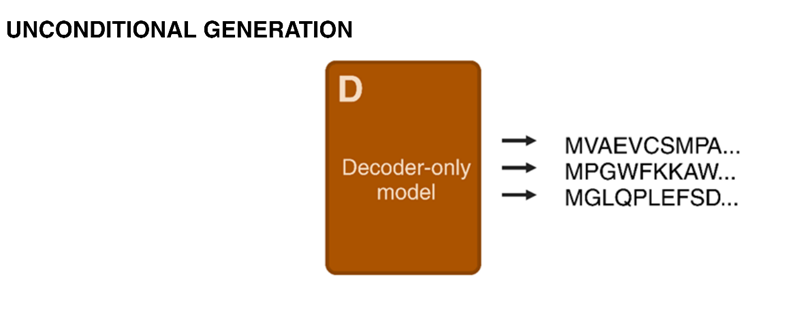

# **3. ProtGPT2 Model** 🔤

* ProtGPT2, creates **protein sequences**, with natural-like properties, but in **new regions of the protein space**.

* PLM published in **2022**, based on the **GPT-2-large Transformer architecture**.

* Training data: UniRef50 database (version 2021_04). Nearly 50M non-annotated sequences.

* Output: proteins with natural like proteins (order, globularity and aminoacid propensity). Expanding natural proteins, producing unreported topologies.

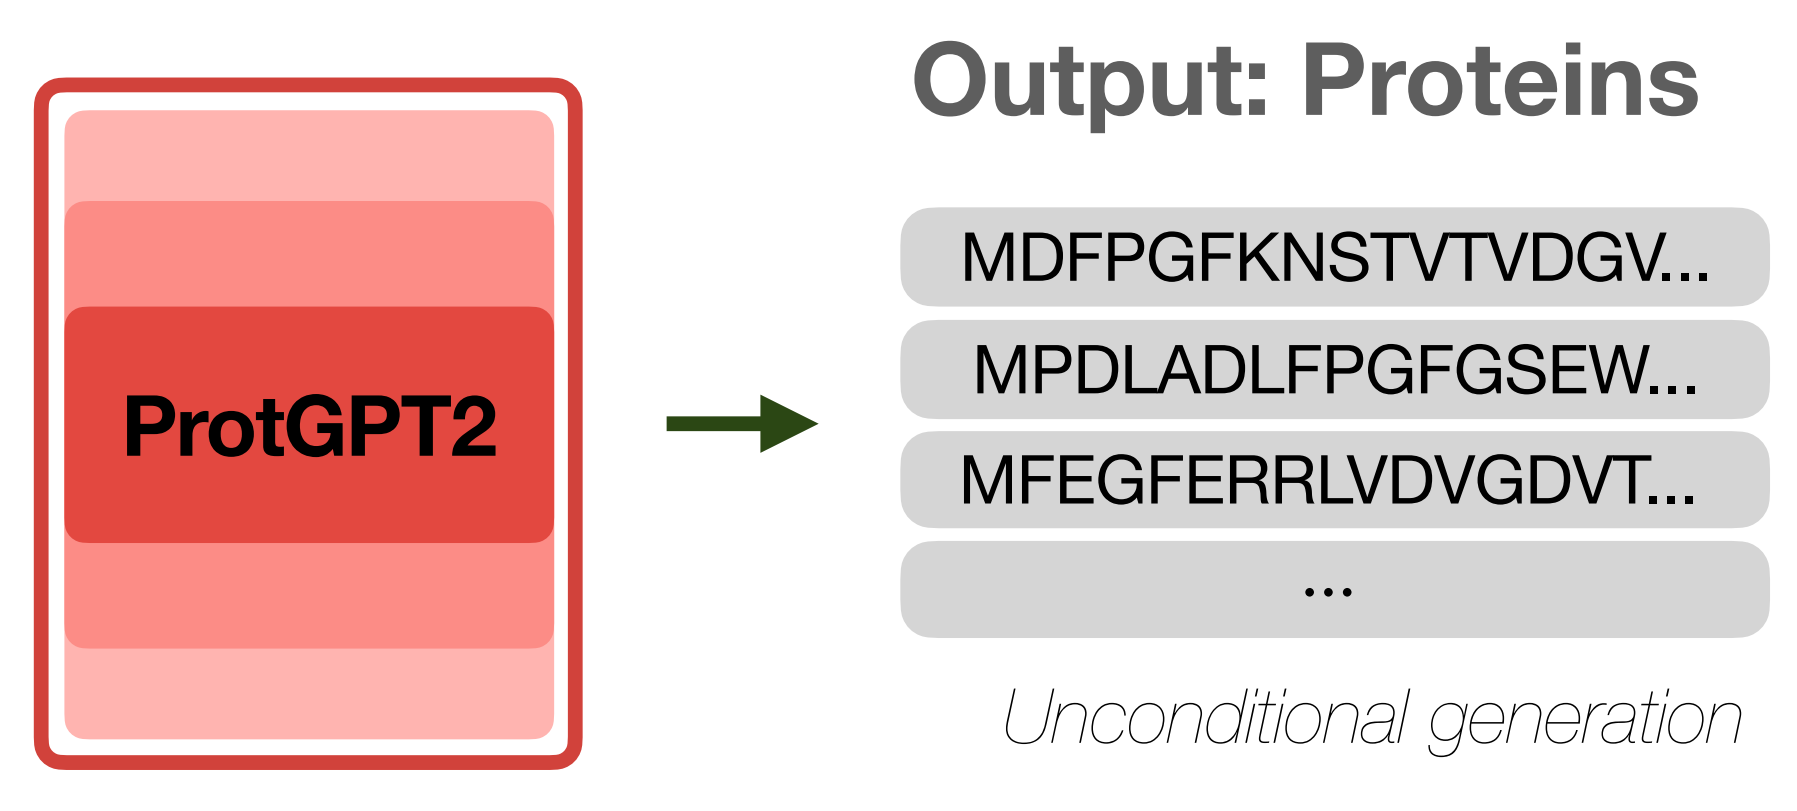

In [ ]:
! pip install transformers
! pip install biopython

In [ ]:
from transformers import pipeline
protgpt2 = pipeline('text-generation', model = "nferruz/ProtGPT2")

input = "<|endoftext|>\nSDKQGTVEVYAAAGWATDNTVMPDGGLQYVLSPYLALDAGYGWANSSLNAAIVGGGVFYPVSPEVVPYVKAGVIYNTDNTAKPFVGAGAKYRLSPDAALVVEYGWFNSSLNSVNAQASYKLTR"
max_length = 125
do_sample = True
repetition_penalty = 1.2
top_k = 950
num_return_sequences = 10
eos_token_id = 0

sequences = protgpt2(input, max_length=max_length, do_sample=do_sample, top_k=top_k, repetition_penalty=repetition_penalty, num_return_sequences=num_return_sequences, eos_token_id=eos_token_id)

# Print sequences
for seq in sequences:
    print(seq['generated_text'])

## **3.1. How to select the best sequences?**
**Perplexity:**

Computing perplexity for each sequence is used because we have observed a correlation between perplexity values with pLDDT.


The lower the perplexity, the better. There is no specific threshold, the best approach is to generate many sequences and then sort them by perplexity to select those with lower values.

Perplexity is a metric that defines how well the model is predicting the next aminoacid in the sequence based in the previous one.


**Matematically computation of perplexity:**
**Perplexity = e^loss**

* e= exponential

*   loss= mesure of the error in the predictions.
It is exponential to convert the logarithmic space back to more intuitive values

In [ ]:
import torch
from transformers import pipeline
from transformers import GPT2LMHeadModel, GPT2Tokenizer
import math


def calculatePerplexity(sequence, model, tokenizer):
    # Tokenizar la secuencia de proteína
    input_ids = torch.tensor(tokenizer.encode(sequence)).unsqueeze(0)
    input_ids = input_ids.to(model.device)

    # Generar las predicciones del modelo y calcular la pérdida
    with torch.no_grad():
        outputs = model(input_ids, labels=input_ids)
    loss, logits = outputs[:2]

    # Calcular la perplejidad
    return math.exp(loss)

model = GPT2LMHeadModel.from_pretrained('nferruz/ProtGPT2')
tokenizer = GPT2Tokenizer.from_pretrained('nferruz/ProtGPT2')

count=0
for seq in sequences:
  count+=1
  ppl = calculatePerplexity(seq['generated_text'], model, tokenizer)
  print(f"sequence{count}:{seq['generated_text']}")
  print(f"perplexity:{ppl}\n")